# VERUS Experimentation #1

**Porto, Portugal**

This notebook assesses the spatiotemporal vulnerability of Porto with the continuous-occupancy
time-window table and four evaluation times, one per activity regime of the week. It uses the same inputs, grid and scenarios
as the multi-domain Contextual Risk Index analysis (`md-contextual-risk-index`, where the table is
named T1g). The experiments of the
IJDRR article (`default_time_windows.csv`, 250 m grid, Sat 10:20 and Mon 08:40, 12:30 and 17:30) are
kept in the git tag `ijdrr-article`.

| Scenario | Regime | Evaluation time |
|---|---|---|
| s1 | Weekday morning rush | Monday 2023-11-06 08:30 |
| s2 | Weekday late morning | Monday 2023-11-06 11:00 |
| s3 | Weekday night | Monday 2023-11-06 21:00 |
| s4 | Saturday daytime | Saturday 2023-11-11 11:00 |

Scenario labels s1–s4 do not correspond to the article's scenarios 1–4.

Method notes:

- Requires verus >= 1.1.1. Vulnerability is normalized with a zero baseline (`value / max_vulnerability`),
  and time windows are applied to the loaded POTIs on every `run()`, so scenarios evaluated in sequence
  do not inherit each other's `vi` values.
- The continuous-occupancy table (`time_windows_continuous_occupancy.csv`) has exclusive window ends, keeps every category active between its
  peaks, and keeps hospitals and stations at a low level at night. Schools are active only at the gates
  (08:00–10:00 and 16:00–18:00).
- The grid has a 100 m edge length and covers the city boundary in `data/cities/`.
- `max_vulnerability` is the largest raw vulnerability over the four scenarios, so the four layers share
  one scale. It was computed with a first pass at `max_vulnerability = 1.0` and is set statically below.
- Maps use CARTO Voyager tiles, which need the `CARTO_API_KEY` environment variable (without it, the
  tiles carry an "API KEY REQUIRED" watermark).


In [1]:
import os
import warnings

import contextily as ctx
import matplotlib.pyplot as plt
import pandas as pd
import xyzservices
from mpl_toolkits.axes_grid1 import make_axes_locatable
from verus import VERUS
from verus.data import TimeWindowGenerator
from verus.grid import HexagonGridGenerator


def carto_voyager():
    """CARTO Voyager tiles, with the API key read from the CARTO_API_KEY environment variable."""
    provider = ctx.providers.CartoDB.Voyager
    key = os.environ.get("CARTO_API_KEY")
    if not key:
        warnings.warn("CARTO_API_KEY is not set: CARTO tiles will show an 'API KEY REQUIRED' watermark")
        return provider
    return xyzservices.TileProvider({**provider, "url": provider["url"] + "?key=" + key})


CARTO_VOYAGER = carto_voyager()


def plot_vulnerability(zones, title):
    """Smoothed vulnerability on a fixed [0, 1] scale over a CARTO basemap."""
    fig, ax = plt.subplots(figsize=(9, 9))
    # Colorbar in an axes appended below the map, so it spans exactly the map width
    cax = make_axes_locatable(ax).append_axes("bottom", size="3%", pad=0.15)
    zones.to_crs(epsg=3857).plot(
        column="VL_normalized_smoothed",
        cmap="YlOrRd",
        vmin=0,
        vmax=1,
        alpha=0.75,
        linewidth=0,
        ax=ax,
        cax=cax,
        legend=True,
        legend_kwds={"label": "Vulnerability (normalized, smoothed)", "orientation": "horizontal"},
    )
    ctx.add_basemap(ax, source=CARTO_VOYAGER, crs="EPSG:3857", attribution_size=6)
    ax.set_title(title)
    ax.set_axis_off()
    plt.show()

## 1. Data Preparation

To ensure reproducibility, we use a pre-fetched POTI dataset and the continuous-occupancy time-window table.

In [2]:
poti_df = pd.read_csv("../../data/poti/porto_dataset_buffered.csv")
time_windows_df = pd.read_csv("../../data/time_windows/time_windows_continuous_occupancy.csv")
scenarios = pd.read_csv("../../data/time_windows/scenarios_activity_regimes.csv")
scenarios

,scenario,regime,evaluation_time
0,s1,Weekday morning rush,2023-11-06 08:30:00
1,s2,Weekday late morning,2023-11-06 11:00:00
2,s3,Weekday night,2023-11-06 21:00:00
3,s4,Saturday daytime,2023-11-11 11:00:00


### 1.1. Generate vulnerability zones

In [3]:
grid_gen = HexagonGridGenerator(region="../../data/cities/porto.geojson", edge_length=100)
hex_grid = grid_gen.run()

2026-09-22 14:19:37 [

INFO

] Initialized grid generator for region from file: porto.geojson


2026-09-22 14:19:37 [

INFO

...

INFO

] Clipping grid to region boundaries


2026-09-22 14:19:38 [

INFO

] Clipped from 4344 to 2965 hexagons


### 1.2. Initialize vulnerability assessment

In [4]:
# max_vulnerability is the largest raw vulnerability (column `value`) over
# the four scenarios, from a first pass with max_vulnerability = 1.0:
#   s1: 0.00026251044805863
#   s2: 0.00017456624797101145
#   s3: 3.478021351414489e-05
#   s4: 0.00023827875547216443
config = {
    "max_vulnerability": {"Porto": 0.00026251044805863},
    "clustering": {
        "optics": {"min_samples": 5, "xi": 0.05, "min_cluster_size": 5},
        "kmeans": {"init": "predefined", "random_state": 42},
    },
}
assessor = VERUS(place_name="Porto", config=config)

2026-09-22 14:19:38 [

INFO

] VulnerabilityAssessor initialized for Porto using gaussian method


### 1.3. Load data

In [5]:
assessor.load(
    potis_df=poti_df,
    time_windows_df=time_windows_df,
    zones_gdf=hex_grid,
)
# The following warnings are expected since the data was not preprocessed.

2026-09-22 14:19:38 [

WARNING

] POTI DataFrame doesn't have 'vi' column. Using default vi=1.


2026-09-22 14:19:38 [

WARNING

...

INFO

] Loaded 2965 vulnerability zones


2026-09-22 14:19:38 [

INFO

] Loaded 128 time window entries


## 2. Vulnerability Assessment

`VL_normalized` reaches 1 in the scenario with the largest raw vulnerability (s1) and stays below 1 in the others.

### 2.1. s1: Weekday morning rush (Monday 2023-11-06 08:30)

In [6]:
evaluation_time = TimeWindowGenerator.to_unix_epoch("2023-11-06 08:30:00")
results = assessor.run(evaluation_time=evaluation_time)
assert results["vulnerability_zones"]["VL_normalized"].max() <= 1 + 1e-12

2026-09-22 14:19:38 [

INFO

] Applying time windows for evaluation time: 1699259400


2026-09-22 14:19:38 [

INFO

...

INFO

] Smoothed vulnerability statistics:


2026-09-22 14:19:49 [

INFO

] count    2965.000000
mean        0.457735
std         0.156887
min         0.098551
25%         0.372633
50%         0.454350
75%         0.546162
max         1.000000
Name: VL_normalized_smoothed, dtype: float64


**Map of the vulnerability zones**

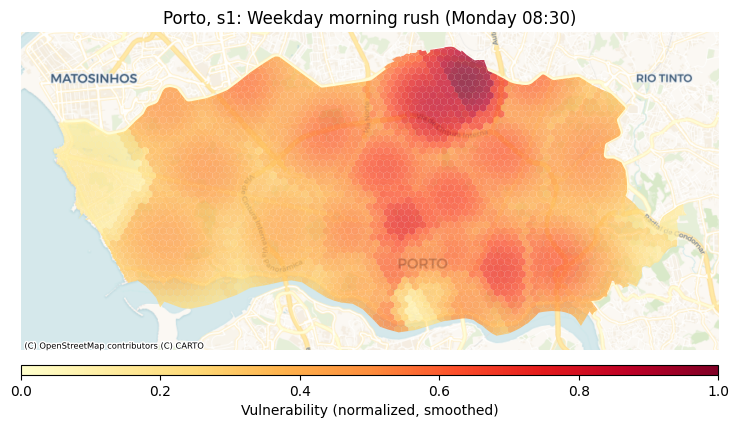

In [7]:
plot_vulnerability(results["vulnerability_zones"], "Porto, s1: Weekday morning rush (Monday 08:30)")

### 2.2. s2: Weekday late morning (Monday 2023-11-06 11:00)

In [8]:
evaluation_time = TimeWindowGenerator.to_unix_epoch("2023-11-06 11:00:00")
results = assessor.run(evaluation_time=evaluation_time)
assert results["vulnerability_zones"]["VL_normalized"].max() <= 1 + 1e-12

2026-09-22 14:19:52 [

INFO

] Applying time windows for evaluation time: 1699268400


2026-09-22 14:19:52 [

INFO

...

INFO

] Smoothed vulnerability statistics:


2026-09-22 14:20:03 [

INFO

] count    2965.000000
mean        0.202684
std         0.135638
min         0.017870
25%         0.109363
50%         0.151840
75%         0.242997
max         0.664951
Name: VL_normalized_smoothed, dtype: float64


**Map of the vulnerability zones**

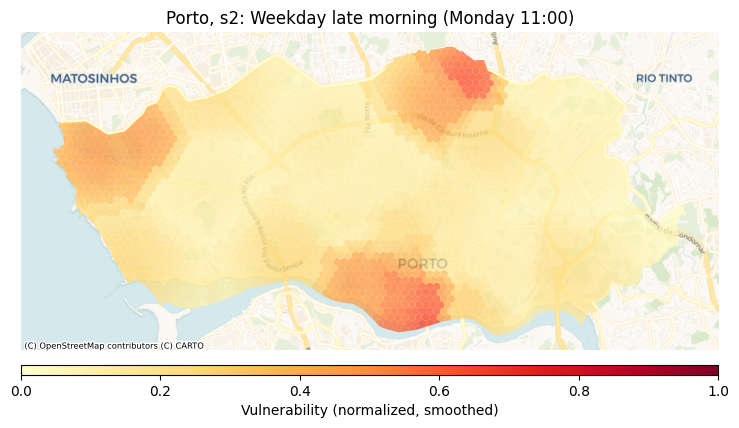

In [9]:
plot_vulnerability(results["vulnerability_zones"], "Porto, s2: Weekday late morning (Monday 11:00)")

### 2.3. s3: Weekday night (Monday 2023-11-06 21:00)

In [10]:
evaluation_time = TimeWindowGenerator.to_unix_epoch("2023-11-06 21:00:00")
results = assessor.run(evaluation_time=evaluation_time)
assert results["vulnerability_zones"]["VL_normalized"].max() <= 1 + 1e-12

2026-09-22 14:20:03 [

INFO

] Applying time windows for evaluation time: 1699304400


2026-09-22 14:20:03 [

INFO

...

INFO

] Smoothed vulnerability statistics:


2026-09-22 14:20:14 [

INFO

] count    2965.000000
mean        0.041612
std         0.030946
min         0.000000
25%         0.011259
50%         0.042888
75%         0.065026
max         0.130461
Name: VL_normalized_smoothed, dtype: float64


**Map of the vulnerability zones**

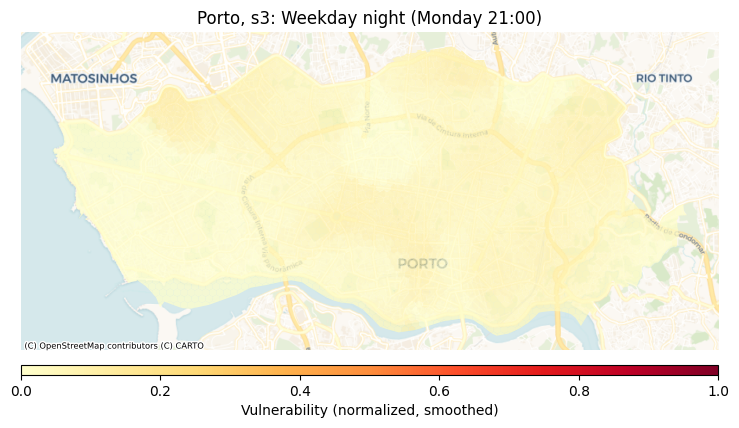

In [11]:
plot_vulnerability(results["vulnerability_zones"], "Porto, s3: Weekday night (Monday 21:00)")

### 2.4. s4: Saturday daytime (Saturday 2023-11-11 11:00)

In [12]:
evaluation_time = TimeWindowGenerator.to_unix_epoch("2023-11-11 11:00:00")
results = assessor.run(evaluation_time=evaluation_time)
assert results["vulnerability_zones"]["VL_normalized"].max() <= 1 + 1e-12

2026-09-22 14:20:14 [

INFO

] Applying time windows for evaluation time: 1699700400


2026-09-22 14:20:14 [

INFO

...

INFO

] Smoothed vulnerability statistics:


2026-09-22 14:20:25 [

INFO

] count    2965.000000
mean        0.156454
std         0.156460
min         0.000000
25%         0.066498
50%         0.100883
75%         0.153287
max         0.906719
Name: VL_normalized_smoothed, dtype: float64


**Map of the vulnerability zones**

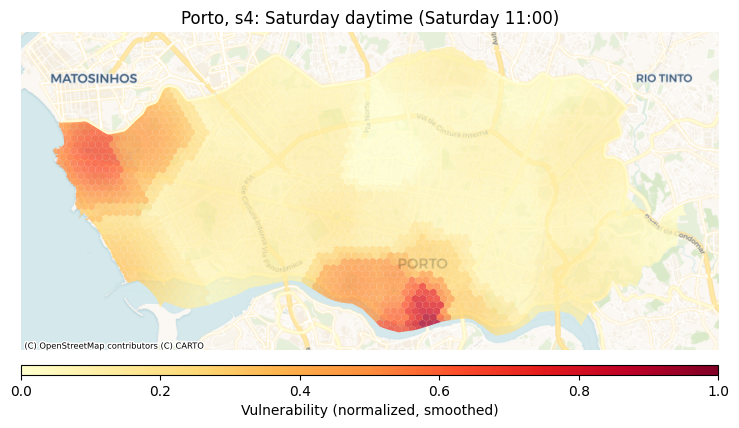

In [13]:
plot_vulnerability(results["vulnerability_zones"], "Porto, s4: Saturday daytime (Saturday 11:00)")